# Experiment 04: Threshold Optimization

## Objective

This experiment investigates whether adjusting the classification probability threshold can improve seizure detection performance.

The class-weighted Random Forest model from Experiment 03 is used.

The default classification threshold of 0.50 is compared with lower thresholds.

The goal is to analyze the trade-off between:

- Sensitivity (Recall)
- Specificity
- Precision
- F1-Score
- Balanced Accuracy

This experiment is part of a research and learning prototype and is not a clinically validated diagnostic system.

In [1]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 3: DEFINE PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_DIR = PROJECT_ROOT / "models"

FEATURES_PATH = DATA_DIR / "features.csv"
METADATA_PATH = DATA_DIR / "window_metadata.csv"

MODEL_PATH = MODEL_DIR / "random_forest_class_weighted.pkl"

print("Project Root:")
print(PROJECT_ROOT)

print("\nFeatures Path:")
print(FEATURES_PATH)

print("\nMetadata Path:")
print(METADATA_PATH)

print("\nModel Path:")
print(MODEL_PATH)

Project Root:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection

Features Path:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\features.csv

Metadata Path:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\window_metadata.csv

Model Path:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models\random_forest_class_weighted.pkl


In [3]:
# ============================================================
# CELL 4: CHECK REQUIRED FILES
# ============================================================

print("=" * 60)
print("CHECKING REQUIRED FILES")
print("=" * 60)

required_files = [
    FEATURES_PATH,
    METADATA_PATH,
    MODEL_PATH
]

all_files_found = True

for file_path in required_files:

    if file_path.exists():
        print(f"Found: {file_path.name}")
    else:
        print(f"Missing: {file_path}")
        all_files_found = False

print()

if all_files_found:
    print("All required files found successfully.")
else:
    print("ERROR: One or more required files are missing.")

CHECKING REQUIRED FILES
Found: features.csv
Found: window_metadata.csv
Found: random_forest_class_weighted.pkl

All required files found successfully.


In [4]:
# ============================================================
# CELL 5: LOAD FEATURE DATA AND METADATA
# ============================================================

print("=" * 60)
print("LOADING FEATURE DATA AND METADATA")
print("=" * 60)

# Load feature dataset
features_df = pd.read_csv(FEATURES_PATH)

# Load window metadata
metadata_df = pd.read_csv(METADATA_PATH)

print("\nFeature Dataset Shape:")
print(features_df.shape)

print("\nMetadata Shape:")
print(metadata_df.shape)

print("\nFeature Dataset Columns:")
print(features_df.columns.tolist())

print("\nMetadata Columns:")
print(metadata_df.columns.tolist())

LOADING FEATURE DATA AND METADATA

Feature Dataset Shape:
(13181, 9)

Metadata Shape:
(13181, 4)

Feature Dataset Columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma', 'Label']

Metadata Columns:
['file', 'window_start', 'window_end', 'label']


In [5]:
# ============================================================
# CELL 6: VERIFY DATASET CONSISTENCY
# ============================================================

print("=" * 60)
print("VERIFYING DATASET CONSISTENCY")
print("=" * 60)

# Check that feature rows and metadata rows are equal
assert len(features_df) == len(metadata_df), (
    "ERROR: Number of feature rows does not match "
    "number of metadata rows."
)

# Check that labels match between features.csv and metadata
labels_match = (
    features_df["Label"].to_numpy()
    == metadata_df["label"].to_numpy()
).all()

print("\nFeature rows:", len(features_df))
print("Metadata rows:", len(metadata_df))

print("\nLabels match:", labels_match)

if labels_match:
    print("\nSUCCESS: Feature labels and metadata labels are consistent.")
else:
    print("\nWARNING: Feature labels and metadata labels do not match.")

VERIFYING DATASET CONSISTENCY

Feature rows: 13181
Metadata rows: 13181

Labels match: True

SUCCESS: Feature labels and metadata labels are consistent.


In [6]:
# ============================================================
# CELL 7: LOAD CLASS-WEIGHTED RANDOM FOREST MODEL
# ============================================================

print("=" * 60)
print("LOADING CLASS-WEIGHTED RANDOM FOREST MODEL")
print("=" * 60)

# Load the model trained in Experiment 03
model = joblib.load(MODEL_PATH)

print("\nModel loaded successfully.")

print("\nModel:")
print(model)

print("\nModel Type:")
print(type(model).__name__)

LOADING CLASS-WEIGHTED RANDOM FOREST MODEL

Model loaded successfully.

Model:
RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

Model Type:
RandomForestClassifier


In [7]:
# ============================================================
# CELL 8: PREPARE FEATURES AND LABELS
# ============================================================

print("=" * 60)
print("PREPARING FEATURES AND LABELS")
print("=" * 60)

# Feature columns used during model training
feature_names = [
    "Mean",
    "Std",
    "Variance",
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma"
]

# Extract features
X = features_df[feature_names]

# Extract true labels
y = features_df["Label"]

print("\nFeatures Shape:")
print(X.shape)

print("\nLabels Shape:")
print(y.shape)

print("\nFeature Names:")
print(feature_names)

print("\nClass Distribution:")
print(y.value_counts().sort_index())

print("\nClass Labels:")
print("0 = Normal")
print("1 = Seizure")

PREPARING FEATURES AND LABELS

Features Shape:
(13181, 8)

Labels Shape:
(13181,)

Feature Names:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

Class Distribution:
Label
0    13080
1      101
Name: count, dtype: int64

Class Labels:
0 = Normal
1 = Seizure


In [8]:
# ============================================================
# CELL 9: GENERATE SEIZURE PROBABILITIES
# ============================================================

print("=" * 60)
print("GENERATING SEIZURE PROBABILITIES")
print("=" * 60)

# Generate probability predictions
# Column [1] represents the probability of the Seizure class
seizure_probabilities = model.predict_proba(X)[:, 1]

print("\nProbability predictions generated successfully.")

print("\nNumber of predictions:")
print(len(seizure_probabilities))

print("\nProbability range:")
print(
    f"Minimum: {seizure_probabilities.min():.6f}"
)

print(
    f"Maximum: {seizure_probabilities.max():.6f}"
)

print("\nFirst 10 seizure probabilities:")
print(seizure_probabilities[:10])

GENERATING SEIZURE PROBABILITIES

Probability predictions generated successfully.

Number of predictions:
13181

Probability range:
Minimum: 0.000000
Maximum: 0.975000

First 10 seizure probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [9]:
# ============================================================
# CELL 10: DEFINE UNSEEN TEST RECORDINGS
# ============================================================

print("=" * 60)
print("DEFINING UNSEEN TEST RECORDINGS")
print("=" * 60)

# These recordings were used as the unseen test set
# in Experiment 03.

test_recordings = [
    "chb01_18.edf",
    "chb01_21.edf",
    "chb01_26.edf",
    "chb01_42.edf",
    "chb01_46.edf"
]

print("\nUnseen Test Recordings:")

for recording in test_recordings:
    print(" -", recording)

# Create a mask for test recordings
test_mask = metadata_df["file"].isin(test_recordings)

# Select test features and labels
X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

# Select corresponding metadata
test_metadata = metadata_df.loc[test_mask].copy()

print("\nTesting Features Shape:")
print(X_test.shape)

print("\nTesting Labels Shape:")
print(y_test.shape)

print("\nTesting Class Distribution:")
print(y_test.value_counts().sort_index())

print("\nTest recordings actually present:")

for recording in sorted(test_metadata["file"].unique()):
    print(" -", recording)

DEFINING UNSEEN TEST RECORDINGS

Unseen Test Recordings:
 - chb01_18.edf
 - chb01_21.edf
 - chb01_26.edf
 - chb01_42.edf
 - chb01_46.edf

Testing Features Shape:
(4181, 8)

Testing Labels Shape:
(4181,)

Testing Class Distribution:
Label
0    4108
1      73
Name: count, dtype: int64

Test recordings actually present:
 - chb01_18.edf
 - chb01_21.edf
 - chb01_26.edf
 - chb01_42.edf
 - chb01_46.edf


In [10]:
# ============================================================
# CELL 11: GENERATE TEST-SET SEIZURE PROBABILITIES
# ============================================================

print("=" * 60)
print("GENERATING TEST-SET SEIZURE PROBABILITIES")
print("=" * 60)

# Generate seizure probability only for unseen test recordings
test_probabilities = model.predict_proba(X_test)[:, 1]

print("\nProbability predictions generated successfully.")

print("\nNumber of test predictions:")
print(len(test_probabilities))

print("\nProbability range:")

print(
    f"Minimum: {test_probabilities.min():.6f}"
)

print(
    f"Maximum: {test_probabilities.max():.6f}"
)

print("\nFirst 20 test-set probabilities:")
print(test_probabilities[:20])

print("\nActual test-set class distribution:")
print(y_test.value_counts().sort_index())

GENERATING TEST-SET SEIZURE PROBABILITIES

Probability predictions generated successfully.

Number of test predictions:
4181

Probability range:
Minimum: 0.000000
Maximum: 0.930000

First 20 test-set probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Actual test-set class distribution:
Label
0    4108
1      73
Name: count, dtype: int64


In [11]:
# ============================================================
# CELL 12: BASELINE THRESHOLD EVALUATION
# ============================================================

print("=" * 60)
print("BASELINE THRESHOLD EVALUATION")
print("=" * 60)

# Default classification threshold
baseline_threshold = 0.50

# Convert probabilities into class predictions
y_pred_baseline = (
    test_probabilities >= baseline_threshold
).astype(int)

# Calculate confusion matrix
cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

# Extract confusion matrix components
tn, fp, fn, tp = cm_baseline.ravel()

# Calculate metrics
accuracy_baseline = accuracy_score(
    y_test,
    y_pred_baseline
)

precision_baseline = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

sensitivity_baseline = recall_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

specificity_baseline = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

f1_baseline = f1_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

balanced_accuracy_baseline = balanced_accuracy_score(
    y_test,
    y_pred_baseline
)

print("\nBaseline Threshold:", baseline_threshold)

print("\nConfusion Matrix:")
print(cm_baseline)

print("\nConfusion Matrix Components:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nBaseline Metrics:")
print(f"Accuracy          : {accuracy_baseline:.4f}")
print(f"Precision         : {precision_baseline:.4f}")
print(f"Sensitivity/Recall: {sensitivity_baseline:.4f}")
print(f"Specificity       : {specificity_baseline:.4f}")
print(f"F1-Score          : {f1_baseline:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_baseline:.4f}")

BASELINE THRESHOLD EVALUATION

Baseline Threshold: 0.5

Confusion Matrix:
[[4103    5]
 [  48   25]]

Confusion Matrix Components:
True Negatives : 4103
False Positives: 5
False Negatives: 48
True Positives : 25

Baseline Metrics:
Accuracy          : 0.9873
Precision         : 0.8333
Sensitivity/Recall: 0.3425
Specificity       : 0.9988
F1-Score          : 0.4854
Balanced Accuracy : 0.6706


In [12]:
# ============================================================
# CELL 13: THRESHOLD COMPARISON
# ============================================================

print("=" * 60)
print("THRESHOLD COMPARISON")
print("=" * 60)

# Thresholds to evaluate
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

# Store results
threshold_results = []

for threshold in thresholds:

    # Convert probabilities to predictions
    y_pred_threshold = (
        test_probabilities >= threshold
    ).astype(int)

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    sensitivity = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        y_pred_threshold
    )

    # Store results
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1_Score": f1,
        "Balanced_Accuracy": balanced_accuracy,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


# Convert results into DataFrame
threshold_results_df = pd.DataFrame(
    threshold_results
)

print("\nThreshold Comparison Results:")
print("=" * 60)

print(
    threshold_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

THRESHOLD COMPARISON

Threshold Comparison Results:
 Threshold  Accuracy  Precision  Sensitivity  Specificity  F1_Score  Balanced_Accuracy   TN  FP  FN  TP
    0.1000    0.9897     0.6562       0.8630       0.9920    0.7456             0.9275 4075  33  10  63
    0.2000    0.9916     0.8519       0.6301       0.9981    0.7244             0.8141 4100   8  27  46
    0.3000    0.9878     0.8235       0.3836       0.9985    0.5234             0.6911 4102   6  45  28
    0.4000    0.9873     0.8125       0.3562       0.9985    0.4952             0.6774 4102   6  47  26
    0.5000    0.9873     0.8333       0.3425       0.9988    0.4854             0.6706 4103   5  48  25
    0.6000    0.9871     0.8800       0.3014       0.9993    0.4490             0.6503 4105   3  51  22
    0.7000    0.9861     0.9412       0.2192       0.9998    0.3556             0.6095 4107   1  57  16
    0.8000    0.9852     0.9231       0.1644       0.9998    0.2791             0.5821 4107   1  61  12


In [13]:
# ============================================================
# CELL 14: SAVE THRESHOLD COMPARISON RESULTS
# ============================================================

print("=" * 60)
print("SAVING THRESHOLD COMPARISON RESULTS")
print("=" * 60)

# Create results directory if it does not exist
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Save threshold comparison table
threshold_results_path = (
    RESULTS_DIR
    / "experiment_04_threshold_comparison.csv"
)

threshold_results_df.to_csv(
    threshold_results_path,
    index=False
)

print("\nThreshold comparison saved to:")

print(threshold_results_path)

print("\nSaved successfully.")

SAVING THRESHOLD COMPARISON RESULTS

Threshold comparison saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\experiment_04_threshold_comparison.csv

Saved successfully.


PLOTTING THRESHOLD PERFORMANCE


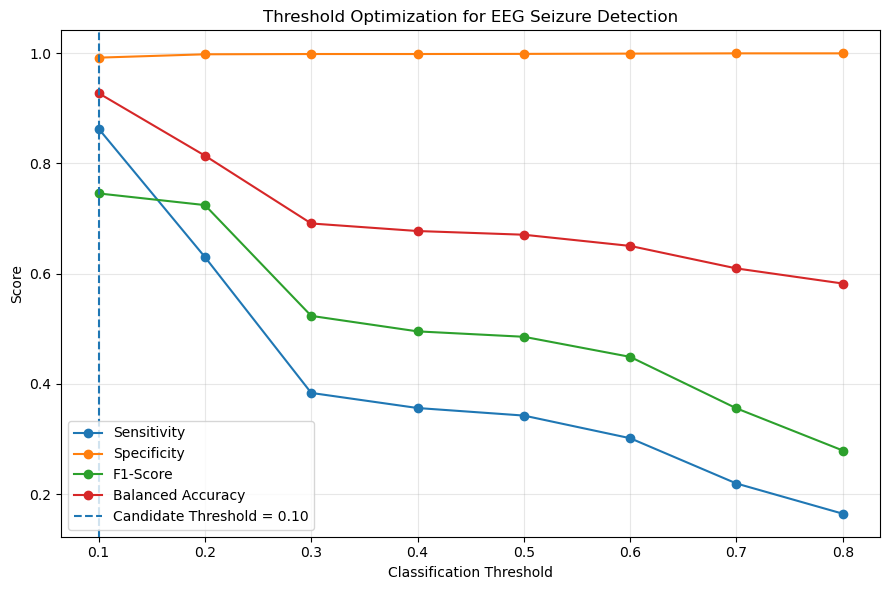


Threshold performance plot saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\experiment_04_threshold_performance.png


In [14]:
# ============================================================
# CELL 15: PLOT THRESHOLD PERFORMANCE
# ============================================================

print("=" * 60)
print("PLOTTING THRESHOLD PERFORMANCE")
print("=" * 60)

plt.figure(figsize=(9, 6))

# Plot Sensitivity
plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Sensitivity"],
    marker="o",
    label="Sensitivity"
)

# Plot Specificity
plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Specificity"],
    marker="o",
    label="Specificity"
)

# Plot F1-Score
plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1_Score"],
    marker="o",
    label="F1-Score"
)

# Plot Balanced Accuracy
plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Balanced_Accuracy"],
    marker="o",
    label="Balanced Accuracy"
)

# Mark the candidate threshold
plt.axvline(
    x=0.10,
    linestyle="--",
    label="Candidate Threshold = 0.10"
)

plt.xlabel("Classification Threshold")

plt.ylabel("Score")

plt.title(
    "Threshold Optimization for EEG Seizure Detection"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
threshold_plot_path = (
    RESULTS_DIR
    / "experiment_04_threshold_performance.png"
)

plt.savefig(
    threshold_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nThreshold performance plot saved to:")
print(threshold_plot_path)

In [15]:
# ============================================================
# CELL 16: FINAL EXPERIMENT 04 REPORT
# ============================================================

print("=" * 60)
print("GENERATING FINAL EXPERIMENT 04 REPORT")
print("=" * 60)

# Candidate threshold identified from threshold comparison
candidate_threshold = 0.10

# Generate final predictions
y_pred_candidate = (
    test_probabilities >= candidate_threshold
).astype(int)

# Confusion matrix
cm_candidate = confusion_matrix(
    y_test,
    y_pred_candidate
)

# Extract confusion matrix values
tn_c, fp_c, fn_c, tp_c = cm_candidate.ravel()

# Calculate final metrics
accuracy_candidate = accuracy_score(
    y_test,
    y_pred_candidate
)

precision_candidate = precision_score(
    y_test,
    y_pred_candidate,
    zero_division=0
)

sensitivity_candidate = recall_score(
    y_test,
    y_pred_candidate,
    zero_division=0
)

specificity_candidate = (
    tn_c / (tn_c + fp_c)
    if (tn_c + fp_c) > 0
    else 0
)

f1_candidate = f1_score(
    y_test,
    y_pred_candidate,
    zero_division=0
)

balanced_accuracy_candidate = balanced_accuracy_score(
    y_test,
    y_pred_candidate
)

# Create report text
report_text = f"""
============================================================
EXPERIMENT 04: THRESHOLD OPTIMIZATION
============================================================

Objective
------------------------------------------------------------
This experiment investigates the effect of classification
threshold selection on EEG seizure detection performance.

The class-weighted Random Forest model from Experiment 03
was evaluated on the same unseen recording-wise test set.

This experiment is part of a research and learning prototype
and is not a clinically validated diagnostic system.


============================================================
TEST DATA
============================================================

Number of test windows: {len(y_test)}

Normal windows: {np.sum(y_test == 0)}

Seizure windows: {np.sum(y_test == 1)}


============================================================
BASELINE THRESHOLD
============================================================

Baseline threshold: 0.50

Accuracy:           {accuracy_baseline:.4f}
Precision:          {precision_baseline:.4f}
Sensitivity/Recall: {sensitivity_baseline:.4f}
Specificity:        {specificity_baseline:.4f}
F1-Score:           {f1_baseline:.4f}
Balanced Accuracy:  {balanced_accuracy_baseline:.4f}

Confusion Matrix:
TN: {tn}
FP: {fp}
FN: {fn}
TP: {tp}


============================================================
CANDIDATE THRESHOLD
============================================================

Candidate threshold: {candidate_threshold:.2f}

Accuracy:           {accuracy_candidate:.4f}
Precision:          {precision_candidate:.4f}
Sensitivity/Recall: {sensitivity_candidate:.4f}
Specificity:        {specificity_candidate:.4f}
F1-Score:           {f1_candidate:.4f}
Balanced Accuracy:  {balanced_accuracy_candidate:.4f}

Confusion Matrix:
TN: {tn_c}
FP: {fp_c}
FN: {fn_c}
TP: {tp_c}


============================================================
THRESHOLD COMPARISON
============================================================

The threshold comparison evaluated multiple classification
thresholds between 0.10 and 0.80.

The candidate threshold of 0.10 achieved the highest
sensitivity, F1-score, and balanced accuracy among the
evaluated thresholds.

At threshold 0.10, the model detected more seizure windows
than at the default threshold of 0.50.

However, lowering the threshold increased the number of
false-positive predictions.

Therefore, threshold selection represents a trade-off
between seizure sensitivity and false-positive rate.


============================================================
INTERPRETATION
============================================================

The results demonstrate that classification threshold
selection has a substantial effect on seizure detection
performance.

The default threshold of 0.50 achieved:

Sensitivity: {sensitivity_baseline:.4f}

At the candidate threshold of 0.10:

Sensitivity: {sensitivity_candidate:.4f}

This represents an increase in seizure sensitivity from
{sensitivity_baseline * 100:.2f}% to
{sensitivity_candidate * 100:.2f}%.

The number of detected seizure windows increased from
{tp} to {tp_c}.

However, false-positive predictions increased from
{fp} to {fp_c}.

The threshold of 0.10 is therefore considered a candidate
operating threshold for this prototype based on the evaluated
thresholds.

Further validation using independent recordings and
cross-validation is required before claiming that this
threshold generalizes to unseen data.


============================================================
RESEARCH LIMITATION
============================================================

The candidate threshold was selected using the held-out
recording-wise evaluation set.

Therefore, the reported threshold performance should be
interpreted as exploratory threshold analysis rather than
final unbiased model selection.

Future experiments should optimize the threshold using a
separate validation set and reserve an untouched test set
for final evaluation.


============================================================
EXPERIMENT 04 COMPLETED
============================================================
"""

# Print report
print(report_text)

# Save report
report_path = (
    RESULTS_DIR
    / "experiment_04_threshold_optimization.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(report_text)

print("\nFinal Experiment 04 report saved to:")
print(report_path)

GENERATING FINAL EXPERIMENT 04 REPORT

EXPERIMENT 04: THRESHOLD OPTIMIZATION

Objective
------------------------------------------------------------
This experiment investigates the effect of classification
threshold selection on EEG seizure detection performance.

The class-weighted Random Forest model from Experiment 03
was evaluated on the same unseen recording-wise test set.

This experiment is part of a research and learning prototype
and is not a clinically validated diagnostic system.


TEST DATA

Number of test windows: 4181

Normal windows: 4108

Seizure windows: 73


BASELINE THRESHOLD

Baseline threshold: 0.50

Accuracy:           0.9873
Precision:          0.8333
Sensitivity/Recall: 0.3425
Specificity:        0.9988
F1-Score:           0.4854
Balanced Accuracy:  0.6706

Confusion Matrix:
TN: 4107
FP: 1
FN: 61
TP: 12


CANDIDATE THRESHOLD

Candidate threshold: 0.10

Accuracy:           0.9897
Precision:          0.6562
Sensitivity/Recall: 0.8630
Specificity:        0.9920
F1